Inspecting data, readiness for clustering:

In [38]:
# import function
%load_ext autoreload
%autoreload 2
from functions import read_file, out_csv, summarise_dataframe
import pandas as pd

yaml_path= "../config.yaml"
inp_data_section='clean_data'
file_name1= 'clean'    
    

#importing data file:
Bdf= read_file(yaml_path, inp_data_section, file_name1) 

print('========================')
summarise_dataframe(Bdf)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Shape: (1083, 11)

--- Null counts ---
Series([], dtype: int64)

--- Dtypes ---
book_name          str
book_url           str
source_list        str
author             str
rating         float64
synopsis           str
pages          float64
pub_date           str
genres             str
img_url            str
data_source        str
dtype: object


In [39]:
#convert to datetime
Bdf['pub_date'] = pd.to_datetime(Bdf['pub_date'], errors='coerce')

#extract the year and cast to a nullable integer
Bdf['pub_date'] = Bdf['pub_date'].dt.year

In [40]:
Bdf.pub_date.unique()

array([2026, 2025, 2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016,
       2015, 2014, 2013, 2012, 2011, 2010, 2009, 2008, 2007, 2006, 2005,
       2004, 2003, 2002, 2001, 2000, 1999, 1998, 1997, 1996, 1995, 1994,
       1993, 1992, 1991, 1990, 1989, 1988, 1987, 1986, 1985, 1984, 1983,
       1982, 1981, 1980, 1979, 1978, 1977, 1976, 1975, 1974, 1973, 1972,
       1971, 1970, 1969, 1968, 1967, 1966, 1965, 1964, 1963, 1962, 1961,
       1960, 1959, 1958, 1957, 1956, 1955, 1954, 1953, 1952, 1951, 1950,
       1949, 1948, 1947, 1946, 1945, 1944, 1943, 1942, 1939, 1938, 1937,
       1936, 1935, 1934, 1933, 1932, 1931, 1929, 1928, 1927, 1926, 1925,
       1924, 1922, 1919, 1918, 1916, 1915, 1911, 1908, 1906, 1905, 1904,
       1888, 1887, 1885, 1879, 1878, 1877, 1871, 1868, 1862, 1861, 1850,
       1847, 1833, 1818, 1813, 1623, 1611, 1605, 1590, 1516, 1909, 1900,
       1811], dtype=int32)

In [41]:
Bdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 1083 entries, 0 to 1082
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   book_name    1083 non-null   str    
 1   book_url     1083 non-null   str    
 2   source_list  1083 non-null   str    
 3   author       1083 non-null   str    
 4   rating       1083 non-null   float64
 5   synopsis     1083 non-null   str    
 6   pages        1083 non-null   float64
 7   pub_date     1083 non-null   int32  
 8   genres       1083 non-null   str    
 9   img_url      1083 non-null   str    
 10  data_source  1083 non-null   str    
dtypes: float64(2), int32(1), str(8)
memory usage: 1.2 MB


In [44]:
books=Bdf.copy()

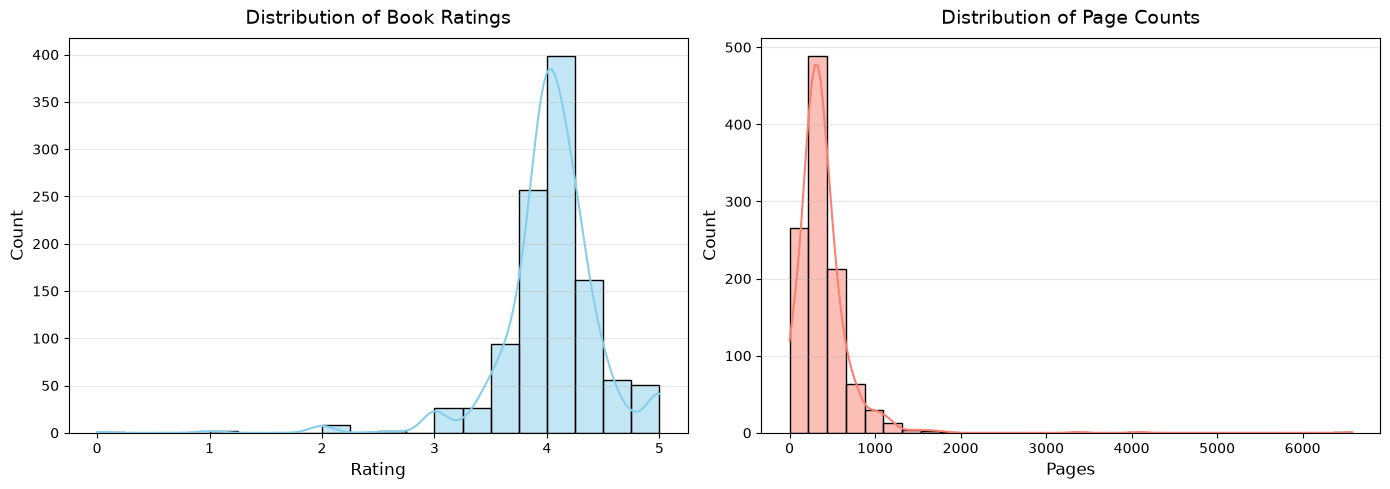

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
#ploting histograms for numeric columns
fig, axes = plt.subplots(1,2, figsize=(14,5))

#left plot
sns.histplot(
    data=books,
    x='rating',
    bins=20,
    kde=True,
    ax=axes[0],
    color='skyblue')
axes[0].set_title('Distribution of Book Ratings', fontsize=14, pad=10)
axes[0].set_xlabel('Rating', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3) #subtle horizontal gridlines

# Right Plot 
sns.histplot(
    data=books, 
    x='pages', 
    bins=30,           # More bins because pages have a wider span (478 unique values)
    kde=True, 
    ax=axes[1], 
    color='salmon'
)
axes[1].set_title('Distribution of Page Counts', fontsize=14, pad=10)
axes[1].set_xlabel('Pages', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()


In [46]:
books[books.pages>1500]

,book_name,book_url,source_list,author,rating,synopsis,pages,pub_date,genres,img_url,data_source
264,The Mortal Instruments Boxed Set: City of Bone...,https://www.goodreads.com/book/show/6485421-th...,Best Book Boyfriends,Cassandra Clare,4.55,"In City of Bones, fifteen-year-old Clary Fray ...",1520.0,2009,Fantasy|Young Adult|Romance|Paranormal|Urban F...,https://m.media-amazon.com/images/S/compressed...,GoodReads
330,Harry Potter Series Box Set,https://www.goodreads.com/book/show/862041.Har...,Best Books of the Decade: 2000s,J.K. Rowling,4.73,"Over 4000 pages of Harry Potter and his world,...",4100.0,2007,Fantasy|Young Adult|Fiction|Harry Potter|Magic...,https://m.media-amazon.com/images/S/compressed...,GoodReads
611,The Complete Aubrey/Maturin Novels,https://www.goodreads.com/book/show/24520.The_...,Best Historical Fiction,Patrick O'Brian,4.76,Patrick O’Brian’s twenty-one-volume Aubrey/Mat...,6576.0,1994,Historical Fiction|Fiction|Historical|Nautical...,https://m.media-amazon.com/images/S/compressed...,GoodReads
714,The Belgariad Boxed Set: Pawn of Prophecy / Qu...,https://www.goodreads.com/book/show/44660.The_...,The Best Epic Fantasy (fiction),David Eddings,4.30,book 1 -- PAWN OF PROPHECY -- A fierce dispute...,1635.0,1984,Fantasy|Fiction|Epic Fantasy|High Fantasy|Scie...,https://m.media-amazon.com/images/S/compressed...,GoodReads
862,J.R.R. Tolkien 4-Book Boxed Set: The Hobbit an...,https://www.goodreads.com/book/show/30.J_R_R_T...,Best Books Ever,J.R.R. Tolkien,4.62,These magical adaptations became instant class...,1728.0,1954,Fantasy|Fiction|Classics|Adventure|Science Fic...,https://m.media-amazon.com/images/S/compressed...,GoodReads
940,The Complete Sherlock Holmes,https://www.goodreads.com/book/show/188572.The...,Best Books of the 20th Century,Arthur Conan Doyle,4.51,A study in scarlet --The sign of four --Advent...,1796.0,1887,Classics|Mystery|Fiction|Crime|Short Stories|A...,https://m.media-amazon.com/images/S/compressed...,GoodReads
955,The Holy Bible: King James Version,https://www.goodreads.com/book/show/1923820.Th...,Books That Everyone Should Read At Least Once,Anonymous,4.45,The King James Version is an Early Modern Engl...,1590.0,1611,Religion|Classics|Nonfiction|Christian|Philoso...,https://m.media-amazon.com/images/S/compressed...,GoodReads
1036,西游记,http://books.google.de/books?id=Pe28AQAACAAJ&d...,Best Books Ever,承恩·吴,4.27,"本书系古典名著《西游记》全文汉英对照本,供文学爱好者、英语学习者阅读.",3355.0,2003,general,https://covers.openlibrary.org/b/id/10324948-L...,google_books


In [47]:
# Keep only books with pages <= 2000
books = books.drop([264,330,611,714,862,1036])
books.shape

(1077, 11)

In [48]:
#Genre frequency
books.genres.unique()

<ArrowStringArray>
[                                                                                                                                                                                                                                                                                                   'Fiction',
                                                                                                                                                                                            'Romance|Sports Romance|Sports|Fake Dating|Contemporary|Forced Proximity|Racing|Young Adult|Contemporary Romance',
                                                                                                                                                                                                                                                                                 'Fantasy|Historical Fiction',
                                                                        

## Genre Cleaning + Feature Objects  
the raw `genres` column has 676 unique combinations across 1008 rows — too much noise and chaos. K-means on that menas curse of dimensionality = garbage clusters.  

**Plan:**  
1. Explode `genres` on `|`, normalize (lowercase + strip), count frequencies  
2. Collapse messy raw tags into a small set of canonical genres via keyword rules  
3. Multi-hot encode → one 0/1 column per canonical genre  
4. Build two DataFrames: `books_display` (raw, for Streamlit UI) and `books_features` (clean, for ML)  

**Null strategy (confirmed):** `rating`, `pages`, `pub_date` stay null — they're excluded from ML features. `synopsis` nulls → filled with `""` so later TF-IDF doesn't choke.

In [49]:
#Explode the '|' separated genre string into a list per book
# Then normalize each tag (lowercase, strip whitespace) so 'Young adult' == 'young adult'

from collections import Counter

def norm_tag(tag):
    return tag.strip().lower()

# Fill NaN genres with empty string so .str.split doesn't break
genre_lists = (
    books['genres']
    .fillna('')
    .str.lower()
    .str.split('|')
    .map(lambda tags: [norm_tag(t) for t in tags if norm_tag(t)])
)

#Flatten to count every tag mention across the whole catalog
all_tags = [t for sub in genre_lists for t in sub]
tag_counts = Counter(all_tags)

print(f'Unique raw tags (after normalization): {len(tag_counts)}')
print(f'Total tag mentions: {len(all_tags)}')
print(f'\nTop 40 raw tags by frequency:')
for tag, count in tag_counts.most_common(40):
    print(f'  {count:>4}  {tag}')

Unique raw tags (after normalization): 519
Total tag mentions: 5087

Top 40 raw tags by frequency:
   709  fiction
   302  fantasy
   241  young adult
   224  classics
   219  romance
   164  historical fiction
   131  audiobook
   117  contemporary
   117  book club
   117  science fiction
   114  historical
   114  adventure
    84  dystopia
    78  literature
    65  high fantasy
    63  childrens
    62  novels
    62  mystery
    60  magic
    60  adult
    59  juvenile fiction
    57  contemporary romance
    56  paranormal
    55  epic fantasy
    54  middle grade
    53  science fiction fantasy
    46  new adult
    43  thriller
    33  post apocalyptic
    32  school
    31  vampires
    31  literary fiction
    30  urban fantasy
    29  mystery thriller
    28  horror
    27  paranormal romance
    24  war
    24  chick lit
    24  humor
    24  general


### Synonym mapping — messy tags → canonical genres  

Rule: for each raw tag, check if any keyword from a canonical genre appears as a substring. A single raw tag can trigger multiple canonicals (e.g. `'science fiction fantasy'` → both `science_fiction` and `fantasy`). That's intentional — cross-genre books are real.  

**Trade-offs to note in the README:**  
- Keyword matching is manual and imperfect. Extend the rules after inspecting Cell 2's top-40 output.  
- I deliberately drop bucket terms like `Fiction`, `Novels`, `Audiobook`, `Ebooks`, `Book Club` — they carry no genre signal. Books with only these tags will end up with zero canonical genres. Count them.

In [72]:
# Collapse raw tags into ~24 canonical genres via keyword rules
GENRE_RULES = {
    'science_fiction':  ['science fiction', 'sci-fi', 'scifi', 'post apocalyptic', 'dystopia', 'post-communism'],
    
    'fantasy':          ['fantasy', 'fae', 'magic', 'vampire', 'paranormal', 'demonology', 'angels', 'merlin (legendary character)', 'ancient guardians', 'earth (planet)'],
    
    'romance':          ['romance', 'romantasy', 'chick lit', 'dating', 'love only', 'yours until dawn', 'love', 'love stories', 'abused wives', 'bodyguards', 'divorced women', 'blind', 'bachelors', 'scotland', 'boy trouble', 'family life'],
    
    'mystery':          ['mystery', 'crime', 'detective', 'noir', 'blessing and cursing', 'thriller', 'suspense', 'sudden death', 'horror', 'fear street'],
    
    'historical':       ['historical fiction', 'historical', 'war', 'false imprisonment', 'veterans', 'monarchy', 'aristocracy', 'inheritance and succession', 'cossacks', 'rum shop', 'great britain', 'south with endurance', 'guy mannering', 'antarctica', 'astrologers'],
    
    'young_adult':      ['young adult', 'ya', 'juvenile', 'college students', 'school', 'adolescent', 'adolescents', 'youth', 'emerging adults', 'emerging adulthood', 'social media and youth', 'cerebral ischemia in young adults', 'media exposure', 'child psychiatry', 'brain'],
    
    'childrens':        ['children', 'childrens', 'picture book', 'middle grade', 'kids', 'brothers and sisters', 'five children', 'dogs', 'behavior', 'brothers', 'toys', 'melody'],
    
    'literary':         ['literary', 'literature', 'novels', 'general', 'tuesdays with morrie', 'autumn', 'criticism', 'essays', 'books and reading', 'africa', 'fathers and daughters', 'the house of mirth', 'new york (n.y.)'],
    
    'classics':         ['classic', 'classics', 'barchester', 'annotated edition', 'illustrated edition', 'annotated', 'illustrated', 'americans', 'accident victims', "anne's house of dreams", 'the castle', 'families', 'authority'],
    
    'contemporary':     ['contemporary', 'book club', 'savor the moment', 'bakers', 'domestic fiction', 'modern', 'state of the union'],

    'adventure':        ['adventure', 'pirates', 'survival', 'voyages'], 

    'fiction':          [
        'fiction', 'fictitious character', 'humor', 'poetry', 'graphic novel', 'comic', 'manga', 'boys',
        'philosophy', 'philosophie', 'psychology', 'amyotrophic lateral sclerosis', 'autism spectrum disorders',
        'history', 'geschichte', 'england', 'brazil', 'brasyl', 'physics', 'biology', 'chemistry', 
        'popular science', 'elephants', 'medical', 'health & fitness', 'self-help', 'self help', 'personal development', 
        'family & relationships', 'business', 'economics', 'finance', 'religion', 'religious', 
        'spirituality', 'christian', 'nonfiction', 'non-fiction', 'memoir', 'biography', 'autobiography', 
        'large print', 'foreign language study', 'large type books', 'trauma', 'pedagogy', 'oncology',
        'musical groups', 'education', 'bays', 'computers', 'electronic books', 'orchestra',
        'the billboard', 'the soda fountain', 'the readers’ advisory guide', 'tuning in', 'sociology', 
        "john brookes' natural landscapes", 'kurzgeschichten', "the author's annual", 'music', 'soda fountains',
        "nullification (states' rights)", 'language arts & disciplines', 'audiobooks', 'political science',
        'gardening', 'allemand (langue)', 'authorship'
    ]
}

def map_tag_to_canonicals(tag):
    return {canon for canon, kws in GENRE_RULES.items() if any(kw in str(tag).lower() for kw in kws)}

books['genres_clean'] = genre_lists.map(
    lambda tags: sorted({c for t in tags for c in map_tag_to_canonicals(t)})
)

n_empty = (books['genres_clean'].map(len) == 0).sum()
print(f'Books with zero canonical genres matched: {n_empty} / {len(books)}')

canonical_counts = Counter(g for sub in books['genres_clean'] for g in sub)
print(f'\nCanonical genre frequencies:')
for g, c in canonical_counts.most_common(12):
    print(f'  {c:>4}  {g}')



Books with zero canonical genres matched: 0 / 1077

Canonical genre frequencies:
   892  fiction
   347  young_adult
   318  fantasy
   244  classics
   232  romance
   209  contemporary
   186  literary
   181  historical
   155  science_fiction
   128  adventure
   104  childrens
    95  mystery


In [73]:
# Show the book name and original raw genres for unmatched books
unmatched_books = books[books['genres_clean'].map(len) == 0]
unmatched_books[['book_name', 'genres']].head(20)

,book_name,genres


In [83]:
books = books.reset_index(drop=True)
books.info()

<class 'pandas.DataFrame'>
RangeIndex: 1077 entries, 0 to 1076
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   book_name     1077 non-null   str    
 1   book_url      1077 non-null   str    
 2   source_list   1077 non-null   str    
 3   author        1077 non-null   str    
 4   rating        1077 non-null   float64
 5   synopsis      1077 non-null   str    
 6   pages         1077 non-null   float64
 7   pub_date      1077 non-null   int32  
 8   genres        1077 non-null   str    
 9   img_url       1077 non-null   str    
 10  data_source   1077 non-null   str    
 11  genres_clean  1077 non-null   object 
dtypes: float64(2), int32(1), object(1), str(8)
memory usage: 1.2+ MB


In [84]:
out_csv(df                  = books,
        yaml_path           = yaml_path,
        output_section_yaml = 'clean_data',
        file_name           = 'clean_st'
)

print(f'Saved {len(books)} records.')

File saved to: ../data/clean/streamlitcatalog.csv
Saved 1077 records.


## Preparing the columns for Unsupervised ML: clustering

In [106]:
#hot-coding genres
from sklearn.preprocessing import MultiLabelBinarizer

# check what genres_clean actually holds
print(books['genres_clean'].iloc[0], type(books['genres_clean'].iloc[0]))

# if list → direct; if 'a|b|c' string → .str.split('|') first
mlb = MultiLabelBinarizer()
genre_matrix = pd.DataFrame(
    mlb.fit_transform(books['genres_clean']),
    columns=[f"genre_{g}" for g in mlb.classes_],
    index=books.index
)
genre_matrix.shape  # hog-encoded matrix of genres, rows are books columns genre_X

['fiction'] <class 'list'>


(1077, 12)

In [107]:
books['pub_date'].describe()  # checking min/max

count    1077.000000
mean     1991.433612
std        39.988829
min      1516.000000
25%      1985.000000
50%      2003.000000
75%      2011.000000
max      2026.000000
Name: pub_date, dtype: float64

In [108]:
#doing a mask to avoid '0' in the features for the clusters
mask_pages  = books['pages']  > 0
mask_rating = books['rating'] > 0

print(mask_pages.sum(), mask_rating.sum())  # rows surviving each filter

1017 1076


In [109]:
#now defining the feature sets
#for clustering, plan:choose features->MinMaxScaler->elbow + silhouette, pick K, inspect clusters manually-> 
#Fit final K-Means, attach cluster labels, reveiw clusters.
feature_sets = {
    'f1_genres':          genre_matrix,
    'f2_genres_pages':    pd.concat([genre_matrix, books[['pages']]], axis=1)[mask_pages],
    'f3_genres_pages_rating': pd.concat([genre_matrix, books[['pages','rating']]], axis=1)[mask_pages & mask_rating],
    'f4_genres_pages_year':   pd.concat([genre_matrix, books[['pages','pub_date']]], axis=1)[mask_pages]}

for name, X in feature_sets.items():
    print(name, X.shape)

f1_genres (1077, 12)
f2_genres_pages (1017, 13)
f3_genres_pages_rating (1016, 14)
f4_genres_pages_year (1017, 14)


In [110]:
#now setting the function to scale the different datasets
from sklearn.preprocessing import MinMaxScaler

def scale_features(X):
    return pd.DataFrame(
        MinMaxScaler().fit_transform(X), columns=X.columns, index=X.index)

In [123]:
import numpy as np

def sweep_k(X, k_range=range(2, 25), min_size=30):
    results = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        sizes = np.bincount(labels)
        results.append({
            'k': k,
            'inertia': km.inertia_,                     #for the elbow method. sum of squared distances of samples to their nearest cluster center (inertia) for various values of K
            'silhouette': silhouette_score(X,labels),   #metric of the separation of the clusters(-1to1), if <0 cluster misallocated, 0:clusters overlap, 1:clusters separated and defined.
            'min_cluster': sizes.min(),
            'n_below_floor': (sizes < min_size).sum(),
        })
    return pd.DataFrame(results)

### Clustering per genres

In [131]:
def decision_plot(df):
    survivors = df[df['n_below_floor'] == 0]
    k_ceiling = survivors['k'].max()
    print(f"Largest k with all clusters ≥ floor: {k_ceiling}")
    
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(df['k'], df['inertia'], marker='o');    ax[0].set_title('Elbow (inertia)')
    ax[1].plot(df['k'], df['silhouette'], marker='o'); ax[1].set_title('Silhouette')
    plt.show()


Largest k with all clusters ≥ floor: 9


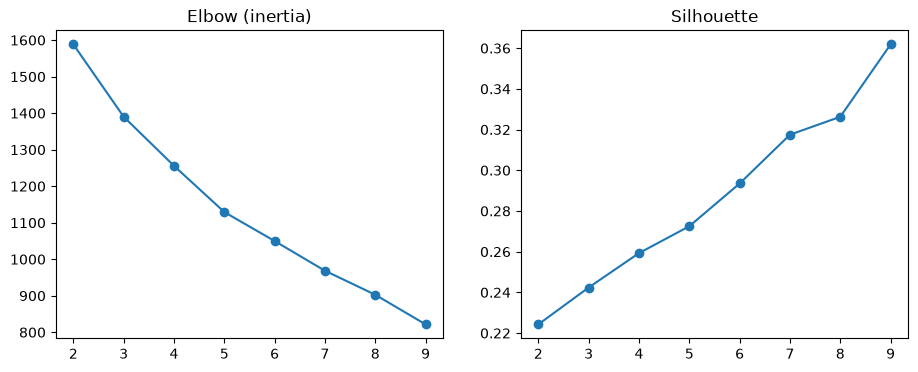

In [132]:
f1 = sweep_k(scale_features(feature_sets['f1_genres']),k_range=range(2,10))

decision_plot(f1)

Clustering per genres does not help much, as Silhouette can be infinite and the elbow method does not have a visual change to denote an important distinction between K.
Genres-only → more clusters carve ever-purer genre-islands, silhouette rewards it to infinity. The metric is broken for this data.

### Clustering: per genres & amount of pages

Largest k with all clusters ≥ floor: 9


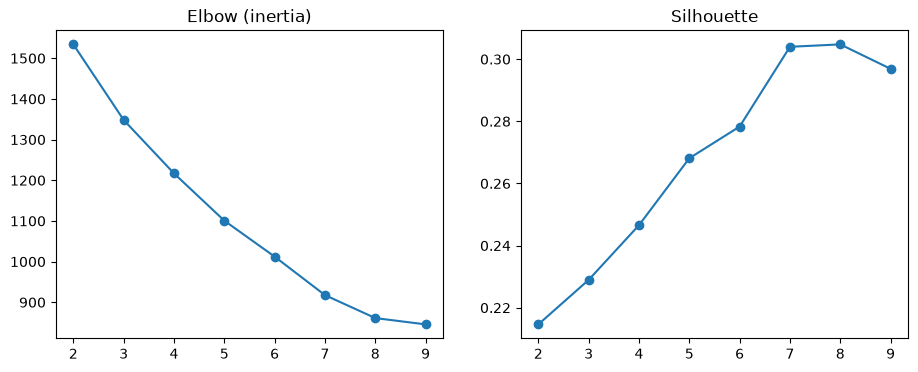

In [136]:
f2 = sweep_k(scale_features(feature_sets['f2_genres_pages']),k_range=range(2,10))
decision_plot(f2)

based on the above, k or n_cluster is set to 7

In [137]:
X = scale_features(feature_sets['f2_genres_pages'])
km2 = KMeans(n_clusters=7, random_state=42, n_init=10)   # k based on the graphs

books.loc[X.index, 'cluster_f2'] = km2.fit_predict(X)
for c in sorted(books['cluster_f2'].dropna().unique()):
    sub = books[books['cluster_f2'] == c]
    print(f"\n=== Cluster {int(c)} | n={len(sub)} | pages μ={sub['pages'].mean():.0f} ===")
    print(sub['genres_clean'].explode().value_counts().head(3))
    print(sub.nlargest(5, 'rating')['book_name'].tolist())


=== Cluster 0 | n=90 | pages μ=350 ===
genres_clean
contemporary    90
romance         84
fiction         62
Name: count, dtype: int64
['Reckless', 'Motorcycle Man', 'Effortless', 'Long Time Coming', 'Reflected in You']

=== Cluster 1 | n=109 | pages μ=308 ===
genres_clean
literary     32
adventure    22
classics     17
Name: count, dtype: int64
['Münchhausen', "Red Rackham's Treasure", 'Ever My Merlin', 'Dating Game', 'Dark Secrets']

=== Cluster 2 | n=140 | pages μ=495 ===
genres_clean
fiction            140
fantasy            136
science_fiction    101
Name: count, dtype: int64
['Blades of Destiny', 'Words of Radiance', 'The Cheat Code', 'The Oldest Dance', 'The High Auction']

=== Cluster 3 | n=104 | pages μ=439 ===
genres_clean
fantasy        101
romance         97
young_adult     92
Name: count, dtype: int64
['A Court of Mist and Fury', 'Clockwork Princess', 'An Echo in the Bone', 'A Breath of Snow and Ashes', 'Lover Awakened']

=== Cluster 4 | n=340 | pages μ=349 ===
genres_cle

### Clustering: per genres, amount of pages & rating

Largest k with all clusters ≥ floor: 9


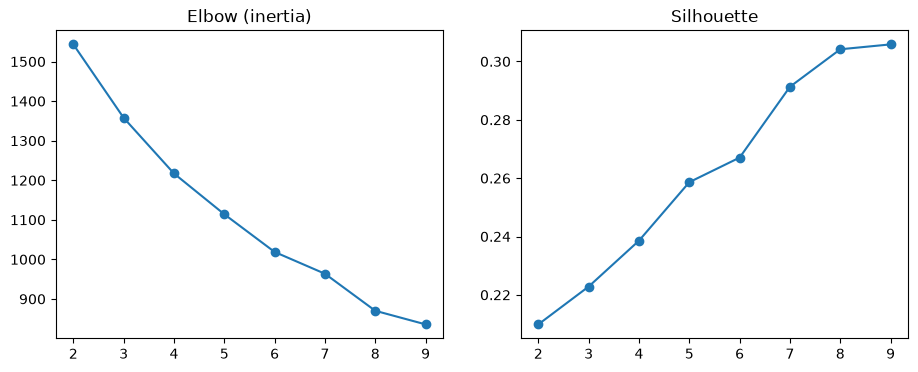

In [138]:
f3 = sweep_k(scale_features(feature_sets['f3_genres_pages_rating']),k_range=range(2,10))
decision_plot(f3)

based on the graphs above k is set to 8

In [139]:
X = scale_features(feature_sets['f3_genres_pages_rating'])
km3 = KMeans(n_clusters=8, random_state=42, n_init=10)   # k based on the graphs

books.loc[X.index, 'cluster_f3'] = km3.fit_predict(X)
for c in sorted(books['cluster_f3'].dropna().unique()):
    sub = books[books['cluster_f3'] == c]
    print(f"\n=== Cluster {int(c)} | n={len(sub)} | pages μ={sub['pages'].mean():.0f}| rating μ={sub['rating'].mean():.0f} ===")
    print(sub['genres_clean'].explode().value_counts().head(3))
    print(sub.nlargest(5, 'rating')['book_name'].tolist())


=== Cluster 0 | n=317 | pages μ=338| rating μ=4 ===
genres_clean
fiction        317
young_adult     61
mystery         34
Name: count, dtype: int64
['Layla', 'There There', 'Rickety Stitch and the Gelatinous Goo', 'Me Before You (Movie Tie-In)', 'A Court of Thorns and Roses']

=== Cluster 1 | n=86 | pages μ=344| rating μ=4 ===
genres_clean
contemporary    86
romance         79
fiction         58
Name: count, dtype: int64
['Reckless', 'Motorcycle Man', 'Effortless', 'Long Time Coming', 'Reflected in You']

=== Cluster 2 | n=132 | pages μ=498| rating μ=4 ===
genres_clean
fiction            132
fantasy            130
science_fiction     98
Name: count, dtype: int64
['Blades of Destiny', 'Words of Radiance', 'The Cheat Code', 'The Oldest Dance', 'The High Auction']

=== Cluster 3 | n=112 | pages μ=472| rating μ=4 ===
genres_clean
fiction     112
classics    109
literary     77
Name: count, dtype: int64
['The Tragedy of King Lear', 'An Ideal Husband', 'Lonesome Dove', 'The Complete Sherloc

### Clustering: per genres, amount of pages & year

Largest k with all clusters ≥ floor: 9


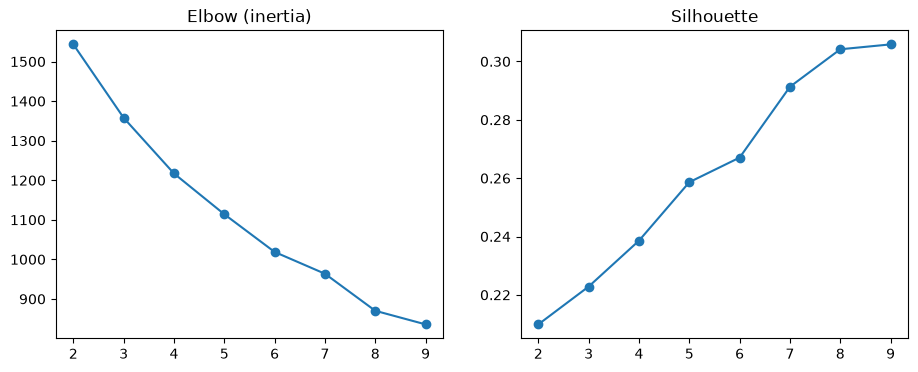

In [140]:
f4 = sweep_k(scale_features(feature_sets['f4_genres_pages_year']),k_range=range(2,10))
decision_plot(f3)

base on the grapsh above k is set to 8

In [142]:
X = scale_features(feature_sets['f4_genres_pages_year'])
km4 = KMeans(n_clusters=8, random_state=42, n_init=10)   # k based on the graphs

books.loc[X.index, 'cluster_f4'] = km4.fit_predict(X)
for c in sorted(books['cluster_f4'].dropna().unique()):
    sub = books[books['cluster_f4'] == c]
    print(f"\n=== Cluster {int(c)} | n={len(sub)} | pages μ={sub['pages'].mean():.0f}| year μ={sub['pub_date'].mean():.0f} ===")
    print(sub['genres_clean'].explode().value_counts().head(3))
    print(sub.nlargest(5, 'rating')['book_name'].tolist())


=== Cluster 0 | n=311 | pages μ=340| year μ=1994 ===
genres_clean
fiction        311
young_adult     61
mystery         32
Name: count, dtype: int64
['Layla', 'There There', 'Rickety Stitch and the Gelatinous Goo', 'Me Before You (Movie Tie-In)', 'A Court of Thorns and Roses']

=== Cluster 1 | n=90 | pages μ=348| year μ=2008 ===
genres_clean
contemporary    90
romance         83
fiction         62
Name: count, dtype: int64
['Reckless', 'Motorcycle Man', 'Effortless', 'Long Time Coming', 'Reflected in You']

=== Cluster 2 | n=83 | pages μ=335| year μ=1982 ===
genres_clean
fiction        82
young_adult    79
childrens      75
Name: count, dtype: int64
['The 13-Storey Treehouse', 'The Tragedy of King Lear', 'Five Go Adventuring Again', 'Harry Potter and the Deathly Hallows', 'Harry Potter and the Half-Blood Prince']

=== Cluster 3 | n=93 | pages μ=331| year μ=1981 ===
genres_clean
literary    93
fiction     61
classics    45
Name: count, dtype: int64
['An Ideal Husband', 'A Story of Yest